## Nivell 1

Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

1. Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.



In [1]:

#REALIZANDO DE NUEVO EL PRIMER EJERCICIO CON SQLALCHEMY para conectar SQL de forma mas actualizada

#instalamos la libreria : pip install SQLAlchemy

#Importamos las herramientas
import pandas as pd
from sqlalchemy import create_engine

#Creamos la "dirección" a la base de datos local
usuario='root'
contraseña='12345'
host='localhost'
database='operations'

cadena_conexion = f"mysql+mysqlconnector://{usuario}:{contraseña}@{host}/{database}"

#Construimos el Motor 
motor = create_engine(cadena_conexion)

#Escribimos nuestra petición (La consulta SQL)
mi_consulta = "SELECT * FROM transactions"

#Pandas hace la entrega usando el motor
df_datos = pd.read_sql(mi_consulta, con=motor)

#Comprobamos que funciona
df_datos.head()


,id,card_id,company_id,timestamp,amount,declined,user_id,lat,longitude
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,4713,46.19992926158272,1.4355402821327607
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,2016-12-21 20:07:18,155.63,0,438,41.59720554463741,12.22175994259365
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,326.01,0,2118,29.757295899964348,-95.37963676492454
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,161.60,0,2115,53.54888376797025,-113.50305274646564
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,148.91,0,3025,52.20836951654172,5.690806474241335


## 2. Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.

Recorda: quan seleccionis les columnes, pensa sempre en el mètode que faràs servir i inclou les que calguin per a la funció de visualització que vulguis utilitzar.

##  Una variable Numerica

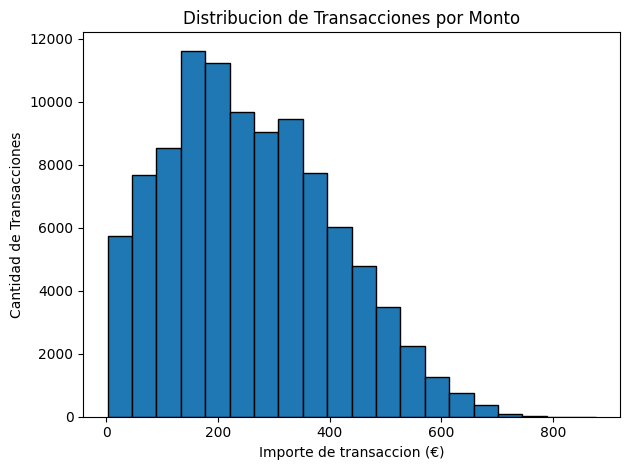

In [1]:
#Realizaremos un grafico tipo histograma para demostrar la frecuencia de las transacciones segun el monto 
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

usuario='root'
contraseña='12345'
host='localhost'
database='operations'

conexion = f"mysql+mysqlconnector://{usuario}:{contraseña}@{host}/{database}"
motor=create_engine(conexion)

#Creamos la tabla transactions, trayendo segun la consulta lo que necesitamos 
transactions="""SELECT * FROM transactions"""
df_transactions=pd.read_sql(transactions,con=motor)
df_filtrado=df_transactions[df_transactions['declined']==0] #evitamos las transacciones declinadas

df_filtrado['amount'].plot(kind="hist",xlabel='Importe de transaccion (€)',ylabel='Cantidad de Transacciones',
                           title='Distribucion de Transacciones por Monto',bins=20,edgecolor='black')
plt.tight_layout() #ajustamos el grafico
plt.show() # Lo mostramos 


## Interpretación de la Visualización (Variable Numérica: Amount)

Tendencia Central: Al observar el histograma, se aprecia claramente que la mayor concentración de las transacciones (la moda) se agrupa en el rango de los 190 a 200 euros por ticket. Se aprecia una distribución clara de asimetría positiva (sesgo a la derecha). A medida que aumenta el importe de la transacción, la frecuencia disminuye drásticamente, mostrando una larga cola hacia los valores más altos.

Hipótesis de Negocio: Este comportamiento sugiere que el "gasto habitual" o el producto estrella de la compañía ronda los 200€. Las compras por importes muy superiores son eventos atípicos o excepcionales dentro del volumen total de ventas.

## Dos variables Numericas

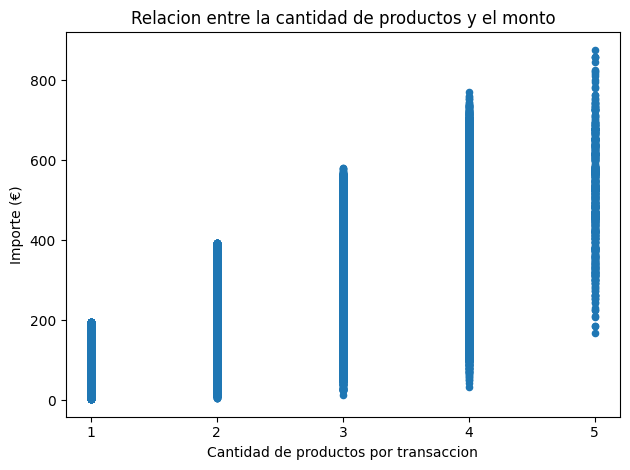

In [2]:
#Realizaremos un grafico de dispersion para demostrar la relacion entre la cantidad de productos y el monto del ticket
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

usuario='root'
contraseña='12345'
host='localhost'
database='operations'

conexion = f"mysql+mysqlconnector://{usuario}:{contraseña}@{host}/{database}"
motor=create_engine(conexion)

#Obtengo las tablas con las consultas
transactions="""SELECT * FROM transactions"""
transaction_products="""SELECT * FROM transaction_products"""

#Creamos los dfs:
df_transactions=pd.read_sql(transactions,con=motor)
df_tp=pd.read_sql(transaction_products,con=motor)

#Eliminamos las transacciones declinadas:
df_t=df_transactions[df_transactions['declined']==0]

#Hacemos Merge para combinar los df y conseguir las variables numericas para el scatter:
df_t_tp=pd.merge(df_t,df_tp, left_on='id', right_on='transaction_id')

df_final=df_t_tp.groupby(['amount','id'])['product_id'].count().reset_index(name='cantidad_productos') #asignamos el nombre de la nueva columna calculada

df_final.plot(kind='scatter',y='amount',x='cantidad_productos',ylabel='Importe (€)',xlabel='Cantidad de productos por transaccion')

#Con el xticks mostramos únicamente valores enteros en el eje X
plt.xticks(range(df_final['cantidad_productos'].min(),df_final['cantidad_productos'].max()+1)) 

plt.title('Relacion entre la cantidad de productos y el monto')
plt.tight_layout()
plt.show()


## Interpretación de la Visualización dos Variables Numéricas: Importe de la transaccion y Cantidad de productos

Correlación Positiva Confirmada: Tal y como demuestra el grafico, existe una correlación positiva clara entre la cantidad de productos adquiridos y el importe final de la transacción. A mayor número de artículos en el carrito, el ticket tiende a ser mayor.

Límite de Gasto por Artículo: Se observa de forma muy marcada que las compras de un solo artículo tienen un tope de gasto cercano a los 200€. Los tickets de alto valor (superiores a 300-400€) no se logran vendiendo un solo producto "premium", sino que siempre son el resultado de cestas con múltiples artículos (3 o más).

# Una variable Categórica

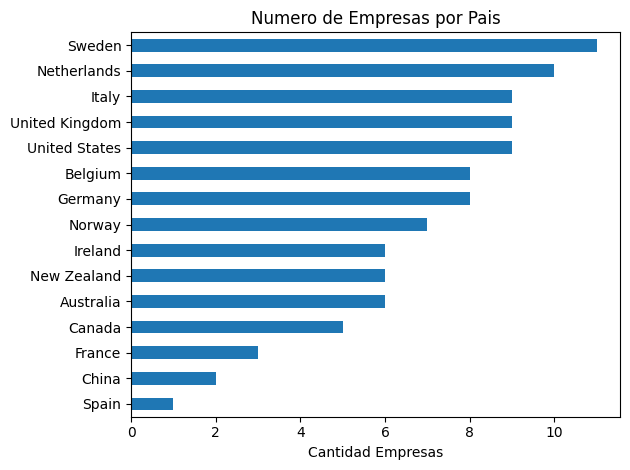

In [3]:
#Realizaremos un grafico tipo barra horizontal donde mostraremos la cantidad de empresas por pais
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

usuario='root'
contraseña='12345'
host='localhost'
database='operations'

conexion = f"mysql+mysqlconnector://{usuario}:{contraseña}@{host}/{database}"
motor=create_engine(conexion)

companies="""SELECT * FROM companies"""

df_companies=pd.read_sql(companies,con=motor)

#Utilizamos el metodo value_counts para agrupar y obetener la frecuencia de empresas por país 
frecuencia=df_companies['country'].value_counts(ascending=True)
frecuencia.plot(kind='barh',y='country')
plt.xlabel('Cantidad Empresas')
plt.ylabel('')
plt.title('Numero de Empresas por Pais')
plt.tight_layout()
plt.show()


### Interpretación y Business Insight: Una variable categórica, Distribución Geográfica de Empresas

La distribución de empresas presenta una jerarquía marcada: Suiza lidera el volumen operativo, seguida por un grupo de mercados secundarios (Holanda, Italia, Reino Unido y EE. UU.) con una presencia equilibrada. En el extremo opuesto, el mercado español muestra una penetración mínima, con una sola entidad registrada.

## Una variable categòrica i una numèrica.

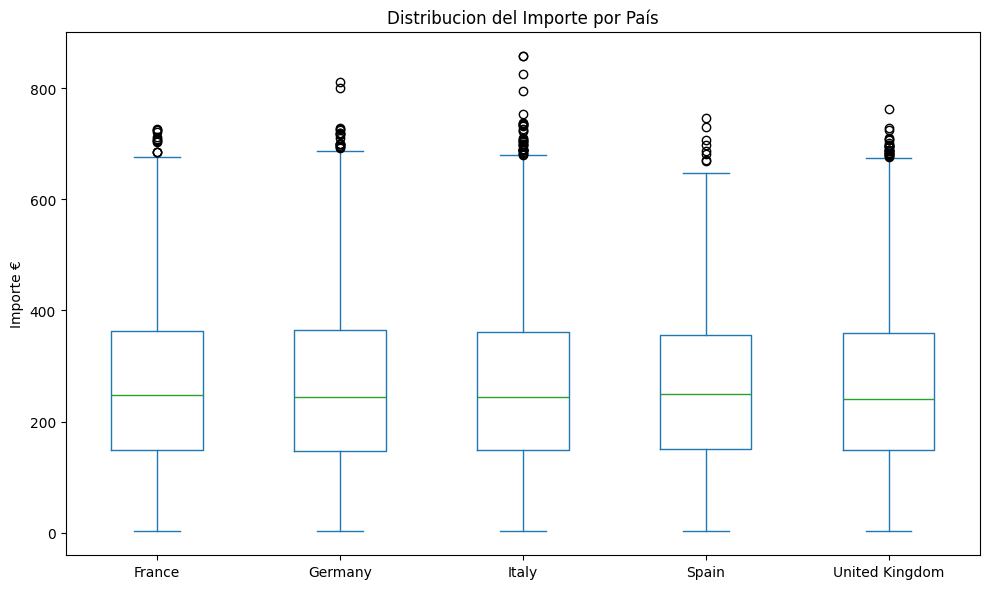

In [4]:
#Realizaremos un grafico tipo boxplot-caja de bigotes donde mostraremos la mediana y el rango de importe por pais
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

usuario='root'
contraseña='12345'
host='localhost'
database='operations'

conexion = f"mysql+mysqlconnector://{usuario}:{contraseña}@{host}/{database}"
motor=create_engine(conexion)

companies="""SELECT * FROM companies"""
transactions="""SELECT * FROM transactions"""

df_companies=pd.read_sql(companies,con=motor)
df_transactions=pd.read_sql(transactions,con=motor)

df_unido=pd.merge(df_transactions,df_companies,left_on='company_id',right_on='id',suffixes=('_transactions','_companies'))

#Como son muchos paises, escogeremos 5 para graficar:
paises=['Spain','France','Germany','Italy','United Kingdom']
df_paises=df_unido[df_unido['country'].isin(paises)]

df_paises.plot(kind='box',column='amount', by='country',figsize=(10,6))
plt.title('Distribucion del Importe por País')
plt.ylabel('Importe €')
plt.tight_layout()
plt.show()


## Interpretación y Business Insight: variable categorica y variable numerica (Distribución de Importes por País)

Comportamiento del Consumidor: El análisis comparativo revela que el importe de las transacciones (amount) presenta una distribución casi idéntica en todos los mercados analizados (Alemania, Reino Unido, Italia, Francia y España). Tanto la mediana (línea central) como el rango intercuartílico (caja) son equiparables en todas las regiones.

Insight de Negocio: Este resultado indica que el patrón de gasto de los clientes es independiente de su ubicación geográfica. La empresa tiene un perfil de cliente global con un comportamiento de compra estandarizado. No es necesario, por tanto, aplicar estrategias de precios diferenciadas por país, ya que el importe medio de ticket es consistente en todo el territorio europeo analizado.

Cabe mencionar que el comportamiento de los valores atípicos (puntos superiores), sería importante analizarlos para averiguar si se trata de clientes premiun, de casos aislados o de errores, lo cual nos permitiria adaptar una estrategia hacia éstos.


## Dos variables Categóricas:


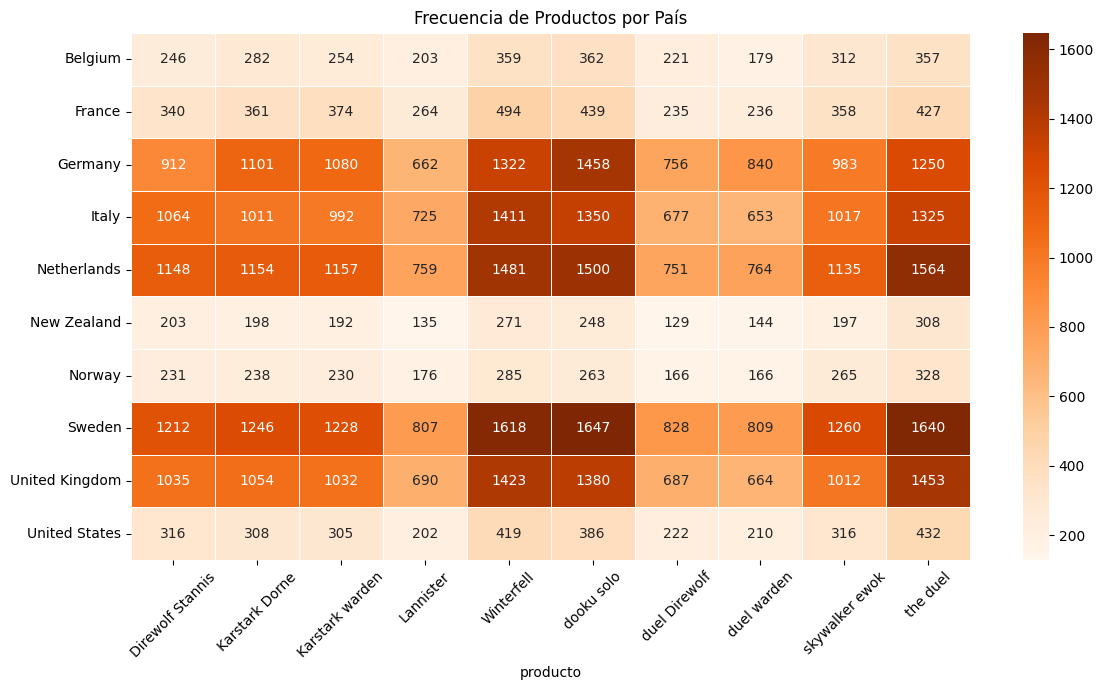

In [5]:
#Realizaremos un gráfico tipo heatmap donde analizaremos la preferencia de productos (cantidad de compras) por pais
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

usuario='root'
contraseña='12345'
host='localhost'
database='operations'

conexion = f"mysql+mysqlconnector://{usuario}:{contraseña}@{host}/{database}"
motor=create_engine(conexion)

transactions="""SELECT * FROM transactions"""
products="""SELECT * FROM products"""
companies="""SELECT * FROM companies """
transaction_products="""SELECT * FROM transaction_products"""

df_transactions=pd.read_sql(transactions,con=motor)
df_products=pd.read_sql(products,con=motor)
df_companies=pd.read_sql(companies,con=motor)
df_transaction_products=pd.read_sql(transaction_products,con=motor)

df_1=pd.merge(df_transactions,df_transaction_products,left_on='id',right_on='transaction_id')
df_2=pd.merge(df_1,df_products,left_on='product_id',right_on='id',suffixes=('_transaction','_product'))
df_final=pd.merge(df_2,df_companies,left_on='company_id',right_on='id')

#Filtramos los 10 Paises y Productos TOP para no saturar el grafico
top_productos=df_final['product_name'].value_counts().nlargest(10).index
top_paises=df_final['country'].value_counts().nlargest(10).index #podemos hacerlo con head(10) porque ya esta ordenado
df_filtrado=df_final[(df_final['country'].isin(top_paises)) & (df_final['product_name'].isin(top_productos))]

#Creamos una matriz para el Heatmap
matriz=pd.crosstab(df_filtrado['country'],df_filtrado['product_name']) #con ,margins obtenemos totales, con normalize porcentajes

plt.figure(figsize=(12,7))
sns.heatmap(matriz,annot=True,fmt='d',cmap='Oranges',linewidths=0.5) #annot para que se muestren los valores,fmt='d' muestra enteros
plt.title('Frecuencia de Productos por País')
plt.xlabel('producto')
plt.ylabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## Interpretación y Business Insight: 2 Variables categóricas
### Matriz de Preferencias Producto-País

Especialización por Mercado: El mapa de calor revela una correlación positiva entre ciertos productos y países específicos. Por ejemplo, se observa que el producto Winterfell lidera sobre 5 de los 10 paises con mas ventas, en los cuales se encuentran Suiza, Holanda, Italia, Alemania y Estados Unidos. A diferencia , productos como Lannister y Duel-Warden muestran un bajo rendimiento comercial. Es notable la debilidad en mercados secundarios (Nueva Zelanda, Noruega, Francia y Bélgica), donde los volúmenes son significativamente inferiores a los esperados.

Insight de Negocio: La disparidad en los resultados sugiere la existencia de barreras de entrada específicas o una falta de alineación con las preferencias locales. Se recomienda ejecutar un análisis en cuanto a las brechas de mercado para determinar si la baja demanda de Lannister se debe a una estrategia de marketing insuficiente o a una desconexión real con las necesidades del consumidor local. Asimismo, el alto rendimiento de Winterfell justifica una estrategia de estandarización en mercados donde aún no ha alcanzado su techo de ventas.

## Tres variables combinadas:


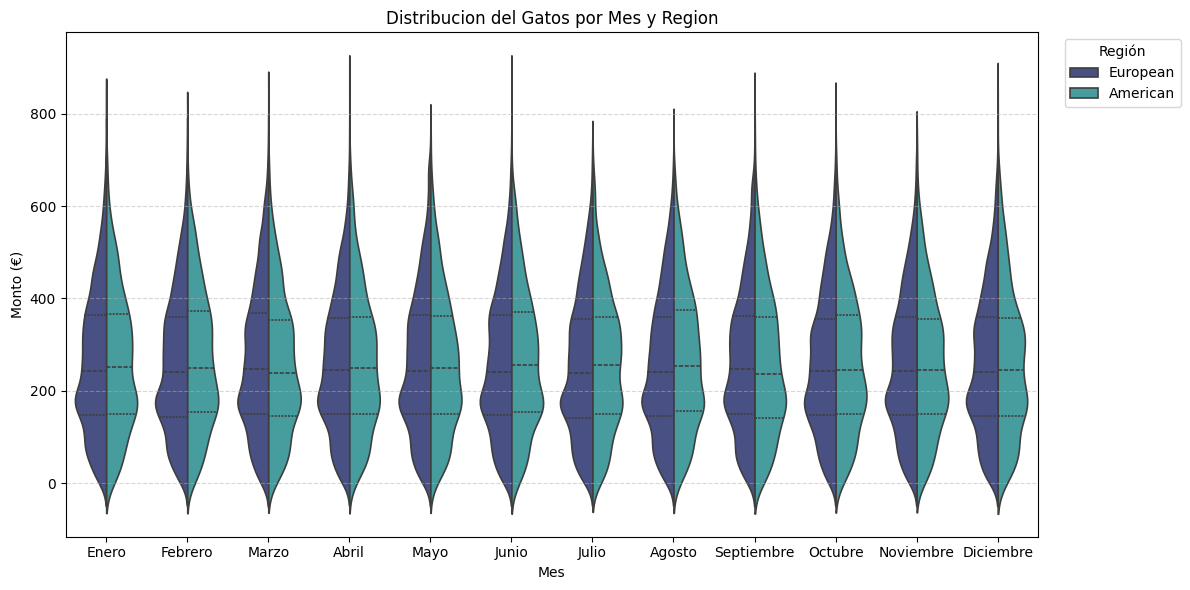

,region,Media,Total
0,American,261.11,5609155.95
1,European,258.44,20292375.22


In [6]:
#Realizaremos un gráfico tipo violin donde analizaremos el gasto de Producto por Mes y Region:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

usuario='root'
contraseña='12345'
host='localhost'
database='operations'

conexion = f"mysql+mysqlconnector://{usuario}:{contraseña}@{host}/{database}"
motor=create_engine(conexion)

transactions="""SELECT * FROM transactions"""
users="""SELECT * FROM users"""

df_transactions=pd.read_sql(transactions,con=motor)
df_users=pd.read_sql(users,con=motor)

df_unido=pd.merge(df_transactions,df_users,left_on='user_id',right_on='id',suffixes=('_transactions','_users'))

#Obtenemos el nombre del mes para el grafico, no hay que convertir a timestamp porque ya python lo ha reconocido
df_unido['mes'] = df_unido['timestamp'].dt.month_name()

#Pasamos a español los meses, creamos un diccionario para reemplazar 
meses = {'January': 'Enero','February': 'Febrero','March': 'Marzo','April': 'Abril','May': 'Mayo','June': 'Junio','July': 'Julio',
    'August': 'Agosto','September': 'Septiembre','October': 'Octubre','November': 'Noviembre','December': 'Diciembre'}

df_unido['mes'] = df_unido['mes'].replace(meses)

#creamos una lista con el orden de los meses para evitar que se ordenen por abecedario
orden = ['Enero','Febrero','Marzo','Abril','Mayo','Junio','Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']

df_unido['mes'] = pd.Categorical(df_unido['mes'],categories=orden,ordered=True)

plt.figure(figsize=(12,6))
sns.violinplot(df_unido, x='mes',y='amount',hue='region',split=True,palette='mako', inner='quartile',linewidth=1.2 )
plt.title('Distribucion del Gatos por Mes y Region')
plt.ylabel('Monto (€)')
plt.xlabel('Mes')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend( title='Región',bbox_to_anchor=(1.02, 1),loc='upper left')
plt.tight_layout()
plt.show()

# Buscamos la media y el total por región para poder interpretar mejor el grafico 
resumen_financiero = df_unido.groupby('region').agg(Media=('amount','mean'),Total=('amount','sum')).reset_index()
resumen_financiero.round(2)


## Análisis Estratégico: Distribución vs. Volumen por Región

El análisis comparativo entre los mercados de Europa y América permite extraer dos conclusiones críticas para la toma de decisiones:

Homogeneidad en el Comportamiento: La distribución de los importes de transacción es prácticamente idéntica en ambas regiones, con una media de gasto por ticket de ~260€. Esto indica que el perfil de cliente y el comportamiento de compra es consistente globalmente.

Brecha de Escala (Oportunidad de Crecimiento): A pesar de la uniformidad en el ticket promedio, existe una diferencia abismal en el volumen total facturado: Europa genera 20.2M€ frente a los 5.6M€ de América. Esto sugiere que América no tiene un problema de rentabilidad por cliente, sino un problema de penetración de mercado. La recomendacion es que no es necesario ajustar precios ni estrategias de producto (dado que el ticket es igual). El foco en América debe ser exclusivamente en estrategias de adquisición masiva para escalar el volumen de transacciones hasta niveles equiparables a Europa.

## Pairplot:

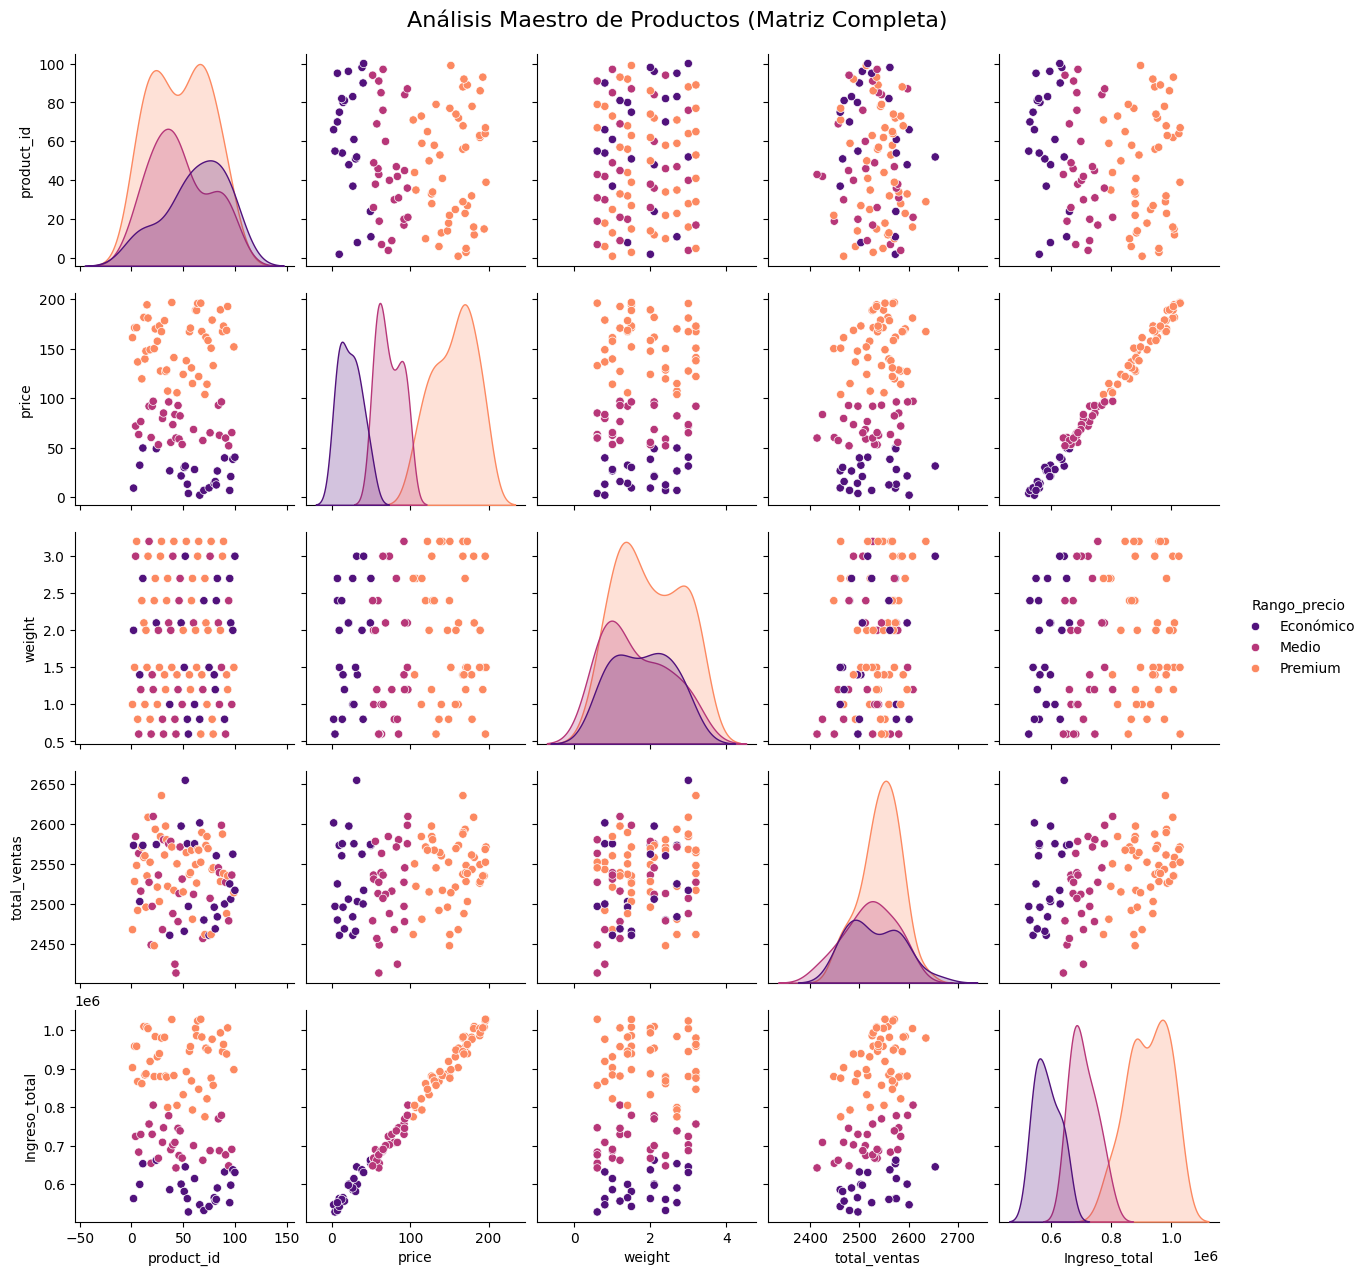

In [7]:
#Realizaremos un gráfico tipo pairplot donde analizaremos las columnas numericas como:
#peso de producto, total ventas, product id, el precio y el ingreso total aplicando 3 categorias de precio por producto

import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

usuario='root'
contraseña='12345'
host='localhost'
database='operations'

conexion = f"mysql+mysqlconnector://{usuario}:{contraseña}@{host}/{database}"
motor=create_engine(conexion)

products="""SELECT * FROM products"""
transaction_products="""SELECT * FROM transaction_products"""
transactions="""SELECT * FROM transactions"""

df_products=pd.read_sql(products,con=motor)
df_transaction_products=pd.read_sql(transaction_products,con=motor)
df_transactions=pd.read_sql(transactions,con=motor)

df_unido=pd.merge(df_products,df_transaction_products,left_on='id',right_on='product_id')
df_unido2=pd.merge(df_unido,df_transactions,left_on='transaction_id',right_on='id',suffixes=('_product','_transaction'))

#creamos una funcion para calcular los rangos con el apply 
def clasificar(precio):
    if precio < 50:
        return 'Económico'
    elif 50 <= precio <= 100:
        return 'Medio' 
    else:
        return 'Premium'

#creamos la columna rango de precio
df_unido2["Rango_precio"]=df_unido2['price'].apply(clasificar)

#aplicamos el orden a la columna creada para el grafico
orden_correcto = ['Económico', 'Medio', 'Premium']
df_unido2['Rango_precio'] = pd.Categorical(df_unido2['Rango_precio'], categories=orden_correcto, ordered=True)

df_agrupado=df_unido2.groupby(['product_id','price','weight','Rango_precio'],observed=True).agg(total_ventas=('id_transaction','count'),
                                                                               Ingreso_total=('amount','sum')).reset_index()

# Graficamos el pairplot
g = sns.pairplot(df_agrupado, hue="Rango_precio", 
    diag_kind="kde", #dibuja curvas de densidad, sino hist, para los histogramas en la diagonal
    corner=False,      #False muestra la matriz completa
    palette="magma",
    height=2.5         
)

g.fig.suptitle("Análisis Maestro de Productos (Matriz Completa)", fontsize=16, y=1.02)
plt.show()

## Análisis del Pairplot: Comportamiento y Estrategia de Productos

Correlación Precio-Ingreso 
Se observa una relación lineal perfecta entre el precio de venta y el ingreso total. Esto confirma que el precio es la variable dominante en nuestra generación de caja. La estrategia de precios actual es altamente predecible. No dependemos de picos masivos de volumen para generar ingresos, sino de la posición de precio de cada producto.

Cualquier ajuste en el margen de beneficio debe centrarse en los productos de alto valor (Premium), ya que son los que definen el techo de nuestros ingresos.

Segmentación de Categorías (Peso vs. Precio)
Los datos muestran una distribución heterogénea: no existe una correlación entre el peso del producto y su categoría de precio (Económico, Medio, Premium). La complejidad logística (peso) es independiente del valor de venta. Tenemos productos Premium (altamente rentables) que son ligeros, y otros que requieren un mayor esfuerzo logístico sin ser necesariamente Premium.

Se Recomienda revisar la rentabilidad neta por producto considerando el coste de envío asociado al peso, para asegurar que los productos pesados no estén drenando el margen de beneficio.

Identificación de Productos Estrella
El análisis de volumen de ventas ha revelado la existencia de un grupo concentrado de "Productos Estrella" (convergencia en torno al ID 100).

La gran mayoría de nuestros productos tienen una rotación moderada ("Long-tail"), mientras que un grupo selecto concentra la mayor parte de las transacciones. Por ende, debemos realizar un análisis profundo de los atributos (características, posicionamiento web, marketing) de estos productos estrella para replicar su éxito en el catálogo de baja rotación.


# Nivell 2

## 1. Representa la correlació d'algunes variables i interpreta els resultats segons les teves dades.

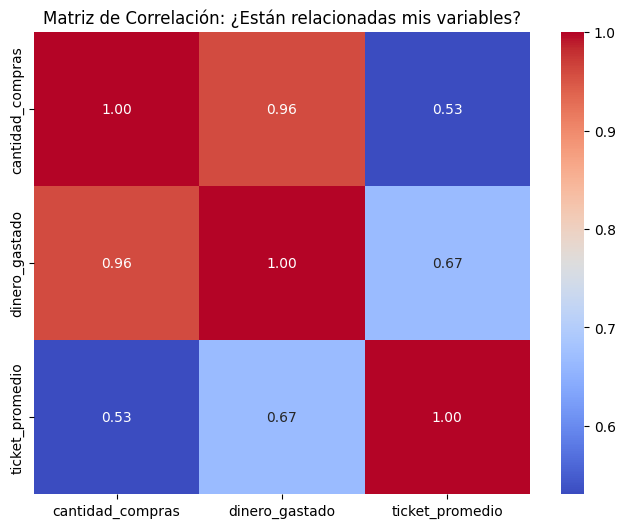

In [8]:
#Realizaremos un gráfico tipo heatmap donde mostraremos la correlacion de las variables numericas: 
# cantidad de compras, dinero gastado y ticket promedio 

import pandas as pd
from sqlalchemy import create_engine
import seaborn as sns
import matplotlib.pyplot as plt

usuario='root'
contraseña='12345'
host='localhost'
database='operations'

conexion = f"mysql+mysqlconnector://{usuario}:{contraseña}@{host}/{database}"
motor=create_engine(conexion)

users="""SELECT * FROM users"""
transactions="""SELECT * FROM transactions"""
transaction_products="""SELECT * FROM transaction_products"""
products="""SELECT * FROM products"""

df_users=pd.read_sql(users,con=motor)
df_transactions=pd.read_sql(transactions,con=motor)
df_transaction_products=pd.read_sql(transaction_products,con=motor)
df_products=pd.read_sql(products,con=motor)

df_unido=pd.merge(df_transactions,df_users,left_on='user_id',right_on='id',suffixes=('_transaction','_user'))
df_unido2=pd.merge(df_unido,df_transaction_products,left_on='id_transaction',right_on='transaction_id')
df_unido3=pd.merge(df_unido2,df_products,left_on='product_id',right_on='id')

#Usamos la funcion para dar categoria 
def clasificar(precio):
   if precio <= 50 :
       return 'Bajo'
   elif precio <= 100:
       return 'Estandar'
   else:
       return 'Premiun' 

df_unido3['Categoria_producto']=df_unido3['price'].apply(clasificar)

#Agrupamos por Usuario y la NUEVA Categoría
df_analisis = df_unido3.groupby(['user_id', 'Categoria_producto']).agg(
    cantidad_compras=('amount', 'count'),    #Frecuencia
    dinero_gastado=('amount', 'sum'),     # Gasto Total
    ticket_promedio=('amount', 'mean')    # Promedio por compra
).reset_index()

# El metodo .corr() solo entiende números, no puede calcular la correlación de texto
df_variables_numericas= df_analisis[['cantidad_compras','dinero_gastado','ticket_promedio']]

#Calculamos la matriz y .corr() nos dirá cuánto se relacionan las variables (de -1 a 1)
matriz = df_variables_numericas.corr()

#Creamos el Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(matriz,annot=True,cmap='coolwarm',fmt='.2f')

plt.title('Matriz de Correlación: ¿Están relacionadas mis variables?')
plt.show()


## Analisis de las correlaciones ejercicio 1 nivel 2:

Al analizar el Heatmap de correlaciones, identificamos patrones muy claros en el comportamiento de los clientes. En primer lugar, existe una relación positiva casi perfecta (0.96) entre la cantidad de compras y el dinero total gastado; indicando una tendencia directa: a mayor frecuencia de compra, mayor es el valor que el cliente aporta a la empresa.

Por otro lado, encontramos un insight de negocio muy valioso: la correlación positiva moderada (0.53) entre la cantidad de compras y el ticket promedio revela que los clientes más frecuentes no solo compran más veces, sino que además tienden a realizar desembolsos mayores en cada visita. 

Finalmente, la correlación positiva moderada-alta (0.67) entre el dinero total gastado y el ticket promedio sugiere que nuestros clientes de mayor valor alcanzan ese nivel de facturación realizando compras de artículos de alto precio, más que por una simple acumulación de compras pequeñas.



## 2. Implementa un Jointplot per explorar la relació entre dues variables i interpreta els resultats segons les teves dades.

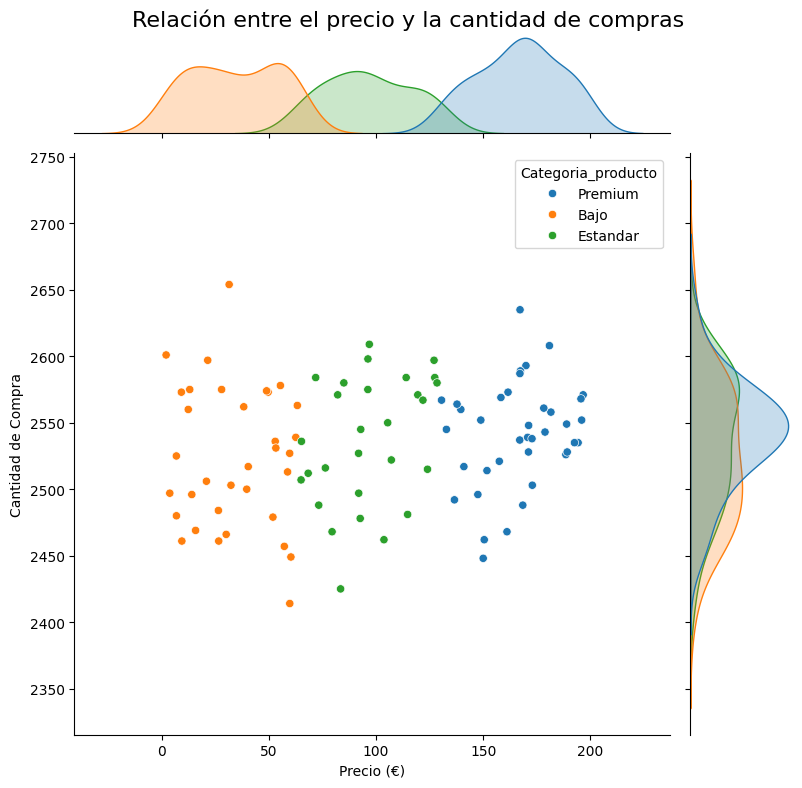

In [9]:
#Realizaremos un gráfico tipo joinplot donde mostraremos la correlacion entre el precio y la cantidad de compra de los productos
#Precio vs. Popularidad del Producto

import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt 
import seaborn as sns 

usuario='root'
contraseña='12345'
host='localhost'
database='operations'

conexion = f"mysql+mysqlconnector://{usuario}:{contraseña}@{host}/{database}"
motor=create_engine(conexion)

products="""SELECT * FROM products"""
transaction_products="""SELECT * FROM transaction_products"""

#Usamos la funcion clasificar para dar color con el hue en el joinplot
def clasificar(precio):
    if precio <= 65:
        return 'Bajo'
    elif precio <=130:
        return 'Estandar'
    else: 
        return 'Premium'

#Creamos los dfs
df_products=pd.read_sql(products,con=motor)
df_transaction_products=pd.read_sql(transaction_products,con=motor)

#Obtenemos la popularidad de los productos:
popularidad=df_transaction_products.groupby('product_id')['transaction_id'].count().reset_index(name='Cantidad_compras')

df_listo=pd.merge(df_products,popularidad,left_on='id',right_on='product_id')
df_listo['Categoria_producto']=df_listo['price'].apply(clasificar)

g=sns.jointplot(df_listo, x='price',y='Cantidad_compras',hue='Categoria_producto',height=8)

g.fig.suptitle('Relación entre el precio y la cantidad de compras', fontsize=16)
g.fig.subplots_adjust(top=0.95)
plt.xlabel('Precio (€)')
plt.ylabel('Cantidad de Compra')
plt.show()



## Analisis insight Gáfico Joinplot 
Al analizar la relación entre el precio del producto y su volumen de ventas, no observamos una correlación directa (los puntos están dispersos). Sin embargo, al observar las distribuciones, descubrimos que los productos de categoría Bajo (verde) tienen el comportamiento más volátil: albergan tanto nuestros mayores éxitos de ventas como productos de menor rotación. Por el contrario, la categoría Premium (azul) muestra un comportamiento mas conservador y predecible, agrupando sus ventas en un volumen medio-bajo constante.
